# 06 - Collaborative Filtering

**Project:** E-Commerce User Behavior Analysis & Recommendation System  
**Notebook purpose:** Builds a category-based collaborative filtering recommendation system from user-category affinity scores derived in notebook 04. Generates top-K category recommendations per user, and evaluates performance using Recall@K.

---

## Environment Setup

This notebook was run on **Kaggle Notebooks** using the affinity dataset produced by `04_feature_engineering.ipynb`.

### To reproduce this notebook

1. Go to the repository on GitHub:  
   [ecommerce-behavior-analysis](https://github.com/halleepham/ecommerce-behavior-analysis)
2. Download `notebooks/06_collaborative_filtering.ipynb`
3. Open a new Kaggle notebook
4. Click **"Add Input"** in the top right panel, search for **kylenaluan/user-category-affinity**, and attach it
5. Run all cells top to bottom

### Data path

All cells in this notebook use the following path to access the affinity data:

    /kaggle/input/user-category-affinity/user_category_affinity.parquet

### Python version and key libraries

| Library | Version |
|---|---|
| Python | 3.12.12 |
| pandas | 2.3.3 |
| numpy | 2.0.2 |
| pyplot | 3.10.0 |
| seaborn | 0.13.2 |
| sklearn | 1.6.1 |

---

## Scope

**Collaborative Filtering:** Builds a category-based collaborative filtering model from user-category affinity scores. Computes a category-category cosine similarity matrix, generates top-K recommendations per user, and evaluates using Recall@K on a leave-one-out train/test split. The similarity matrix is saved for reuse in notebook 08.

In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# File paths
AFFINITY_FILE = '/kaggle/input/datasets/kylenaluan/user-category-affinity/user_category_affinity.parquet'
OUTPUT_DIR = '/kaggle/working'

# Constants
SAMPLE_SIZE = None # full dataset used after verifying pipeline (sampling not required)
K = 5 # number of recommendations per user
RANDOM_SEED = 42 # for reproducibility

# Verify file exists
print(f'File exists: {os.path.exists(AFFINITY_FILE)}')

# Check import versions
print(f'Python: {sys.version}')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')
print(f'pyplot: {plt.matplotlib.__version__}')
print(f'seaborn: {sns.__version__}')
print(f'sklearn: {__import__("sklearn").__version__}')

File exists: True
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
pandas: 2.3.3
numpy: 2.0.2
pyplot: 3.10.0
seaborn: 0.13.2
sklearn: 1.6.1


---

## 1. Exploratory Data Analysis

* Before building the model, I explore the affinity dataset to understand its structure and distributions.
* This informs several decisions made later in the notebook, including the minimum affinity threshold and what counts as a "relevant" recommendation during evaluation.

### 1.1 Data Structure
Load the affinity dataset and inspect its shape, column types, and first few rows.

In [3]:
affinity_df = pd.read_parquet(AFFINITY_FILE)

print(f'Shape: {affinity_df.shape}\n')

print('---Column data types---')
print(f'{affinity_df.dtypes}\n')

print('---First 5 rows---')
print(affinity_df.head())

Shape: (6753416, 6)

---Column data types---
event_type
user_id            int32
main_category     object
cat_carts          int64
cat_purchases      int64
cat_views          int64
affinity_score     int64
dtype: object

---First 5 rows---
event_type   user_id main_category  cat_carts  cat_purchases  cat_views  \
0           29515875   electronics          0              0          5   
1           29515875     furniture          0              0          6   
2           31198833    appliances          0              0          1   
3           31198833   electronics          0              0         18   
4           33869381          kids          0              0          1   

event_type  affinity_score  
0                        5  
1                        6  
2                        1  
3                       18  
4                        1  


In [4]:
print(f'\nNumber of unique categories: {affinity_df["main_category"].nunique()}')
print(f'Categories: {sorted(affinity_df["main_category"].unique())}')


Number of unique categories: 13
Categories: ['accessories', 'apparel', 'appliances', 'auto', 'computers', 'construction', 'country_yard', 'electronics', 'furniture', 'kids', 'medicine', 'sport', 'stationery']


#### Data Structure Observations
* The dataset has 6,753,416 rows and 6 columns
* 13 unique categories
* Each row represents one user-category pair (case/observation definition)
* A single user can appear multiple times, once per category they interacted with
* `affinity_score` is an `int64`. Makes sense since it is a weighted sum of integer event counts (not decimals)
* Looking at the first 5 rows, the affinity scores for these users are low, and all interactions are views only (no cart or purchases)
* We know that low-activity users are common in the dataset. This is important when I decide the minimum affinity threshold

### 1.2 Affinity Score Distribution
* Examine the distribution of affinity scores across all user-category pairs. 
* This will inform my decision on whether to apply a minimum/maximum affinity threshold before building the interaction matrix

In [5]:
print('--- Affinity score statistics ---')
print(affinity_df['affinity_score'].describe().round(3), '\n')

--- Affinity score statistics ---
count    6753416.000
mean          12.630
std           32.389
min            1.000
25%            1.000
50%            4.000
75%           11.000
max        13785.000
Name: affinity_score, dtype: float64 



* The 25th percentile is 1, meaning at least 25% of all user-category pairs have a score of exactly 1. Minimum is also 1
* median is only 4, meaning half of all interactions are a score of 4 or below. A majority of users have very "thin" interaction histories
* Max is 13,785, meaning there is some extremely active users pulling the mean up to 12.6, which is why the mean is so much higher than the median. Right-skewed distibution
* The standard deviation of 32 relative to the mean of 12 shows that the distibution is very spread out

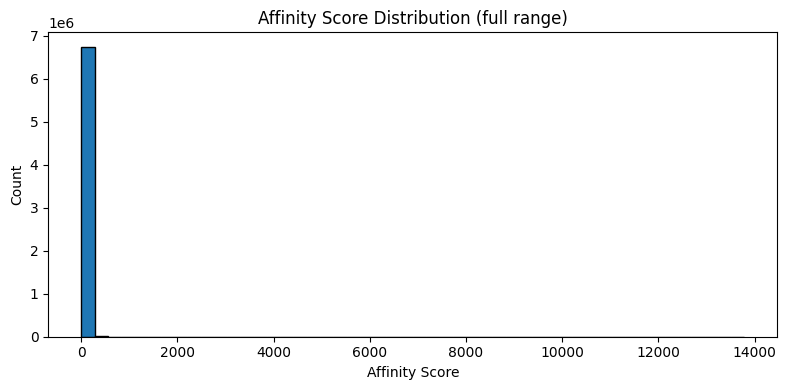

In [6]:
plt.figure(figsize=(8, 4))
plt.hist(affinity_df['affinity_score'], bins=50, edgecolor='black')
plt.title('Affinity Score Distribution (full range)')
plt.xlabel('Affinity Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

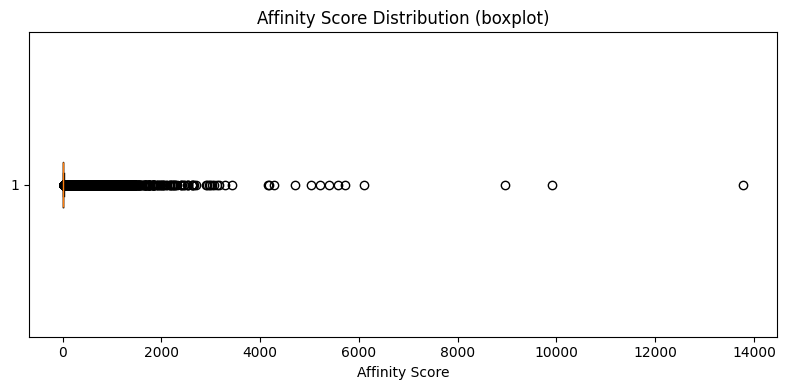

In [7]:
plt.figure(figsize=(8, 4))
plt.boxplot(affinity_df['affinity_score'], vert=False)
plt.title('Affinity Score Distribution (boxplot)')
plt.xlabel('Affinity Score')
plt.tight_layout()
plt.show()

As seen by the two visualizations above, the skew of the distribution is so extreme that any full-range visualization is going to be unreadable. So, a more zoomed in plot of the data will give us more information.

In [8]:
p95 = affinity_df['affinity_score'].quantile(0.95)
p99 = affinity_df['affinity_score'].quantile(0.99)

print(f'95th percentile: {p95}')
print(f'99th percentile: {p99}')

95th percentile: 52.0
99th percentile: 131.0


Given that the median is only 4 and 95% of the data is below 52, I zoom the plot in to the 95th percentile. This is where the vast majority of the users live, which is an important range for understanding the bulk of the distribution to make a threshold decision. 

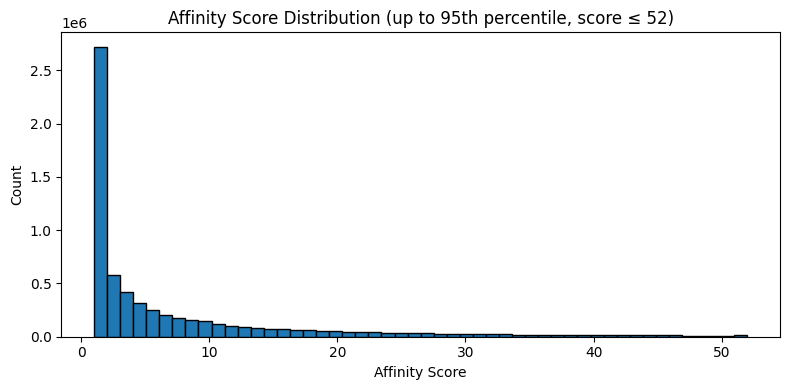

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(affinity_df[affinity_df['affinity_score'] <= p95]['affinity_score'], 
         bins=50, edgecolor='black')
plt.title(f'Affinity Score Distribution (up to 95th percentile, score ≤ {p95:.0f})')
plt.xlabel('Affinity Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### Looking into more patterns for upper threshold and filtering decisions:

In [10]:
print('--- Users above 99th percentile (score > 131) ---')
extreme = affinity_df[affinity_df['affinity_score'] > p99]
print(f'Number of rows: {len(extreme):,}')
print(f'Number of unique users: {extreme["user_id"].nunique():,}')
print(f'Percentage of total rows: {len(extreme) / len(affinity_df) * 100:.2f}%')
print(f'\n--- Affinity score statistics for extreme users ---')
print(extreme['affinity_score'].describe().round(2))

--- Users above 99th percentile (score > 131) ---
Number of rows: 66,798
Number of unique users: 63,422
Percentage of total rows: 0.99%

--- Affinity score statistics for extreme users ---
count    66798.00
mean       226.30
std        171.47
min        132.00
25%        151.00
50%        181.00
75%        244.00
max      13785.00
Name: affinity_score, dtype: float64


* The top 1% of scores represent 63,422 unique users. This means that the majority of these extreme users have only one category
* The median is 181, and the 75th percentile is 244, meaning that within this extreme group, most scores are relatively modest
* This means "truly" extreme scores (like 13,785) are outliers even among outliers.


---

Looking at the top 10 observations with the highest affinity score:

In [11]:
# Top 10 scores
top_10 = affinity_df.nlargest(10, 'affinity_score')
top_10

event_type,user_id,main_category,cat_carts,cat_purchases,cat_views,affinity_score
5850740,569335945,kids,0,0,13785,13785
35455,512365995,electronics,18,0,9861,9915
86191,512475445,auto,0,0,8964,8964
5760882,568778435,appliances,0,0,6103,6103
5269839,564068124,electronics,557,630,890,5711
99287,512505687,electronics,9,3,5529,5571
776372,514649263,kids,1,0,5392,5395
46672,512388419,electronics,7,1,5189,5215
305679,513021392,electronics,206,64,4091,5029
2961557,538473314,electronics,347,268,2333,4714


* The user with the top affinity score viewed products in the kids category almost 14,000 times, but never once added anything to their cart or bought anything. This could be a bot or a crawler.
* The first 4 don't have purchases
* 10/15 are in the electronics category
* These are extreme outliers that may not be useful, so I will look more into an upper bound threshold.

I'll look into whether scores in this high range are driven by purchase and carts, or purely views like the 13,785 case we saw:

In [12]:
print('--- Event breakdown for extreme users ---')
print(f'Rows with 0 purchases and 0 carts: {((extreme["cat_purchases"] == 0) & (extreme["cat_carts"] == 0)).sum():,}')
print(f'Rows with at least 1 purchase: {(extreme["cat_purchases"] > 0).sum():,}')
print(f'Rows with at least 1 cart: {(extreme["cat_carts"] > 0).sum():,}')
print(f'\n--- Average event counts for extreme users ---')
print(extreme[['cat_views', 'cat_carts', 'cat_purchases']].mean().round(2))

--- Event breakdown for extreme users ---
Rows with 0 purchases and 0 carts: 9,895
Rows with at least 1 purchase: 39,499
Rows with at least 1 cart: 54,549

--- Average event counts for extreme users ---
event_type
cat_views        176.74
cat_carts          9.08
cat_purchases      4.46
dtype: float64


* ~81% of extreme users have at least one cart addition (54,549/66,798)
* 51% have at least one purchase (39,499 out of 66,798)
* only 14.8% are pure view
These seem like genuinely engaged users. So the top affinity score observations may have been an anomaly.

In [13]:
# Isolate pure view-only users across entire dataset
view_only = affinity_df[
    (affinity_df['cat_purchases'] == 0) & 
    (affinity_df['cat_carts'] == 0)
]

print('--- Pure view-only user-category pairs (no carts or purchases) ---')
print(f'Total rows: {len(view_only):,}')
print(f'Percentage of dataset: {len(view_only) / len(affinity_df) * 100:.2f}%')
print(f'\n--- Affinity score statistics for view-only pairs ---')
print(view_only['affinity_score'].describe().round(2))

--- Pure view-only user-category pairs (no carts or purchases) ---
Total rows: 5,660,116
Percentage of dataset: 83.81%

--- Affinity score statistics for view-only pairs ---
count    5660116.00
mean           6.83
std           16.69
min            1.00
25%            1.00
50%            3.00
75%            7.00
max        13785.00
Name: affinity_score, dtype: float64


* 83% or all user-category pairs have zero carts and purchases.
* However, the median affinity score is only 3, and 75th percentile is only 7, meaning most of these view-only pairs have very low scores, so no purchases or carts make sense
* The real concern is the small number of view-only pairs that accumulate extremely high scores (like the 13,785 case), where massive view counts produce inflated affinity scores that don't reflect genuine purchase intent.
* Because 83.81% of the dataset is view-only, requiring at least one cart or 
purchase from every user-category pair would remove the majority of our data. 
That is too aggressive and would severely worsen the cold start problem
* A more targeted approach would be to only cap pure view-only pairs that have 
extremely high scores, rather than removing all view-only pairs entirely

In [14]:
print('--- View-only affinity score percentiles ---')
print(view_only['affinity_score'].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).round(2))

--- View-only affinity score percentiles ---
0.25     1.0
0.50     3.0
0.75     7.0
0.90    16.0
0.95    25.0
0.99    62.0
Name: affinity_score, dtype: float64


* The view-only distribution is much more compressed than the full dataset
* The 99th percentile is only 62 (it was 131 for the full dataset)
* This makes sense because without carts (x3) and purchases (x5) inflating the score, the only way to get a high score is through a lot of views

Zooming into the 99th percentile:

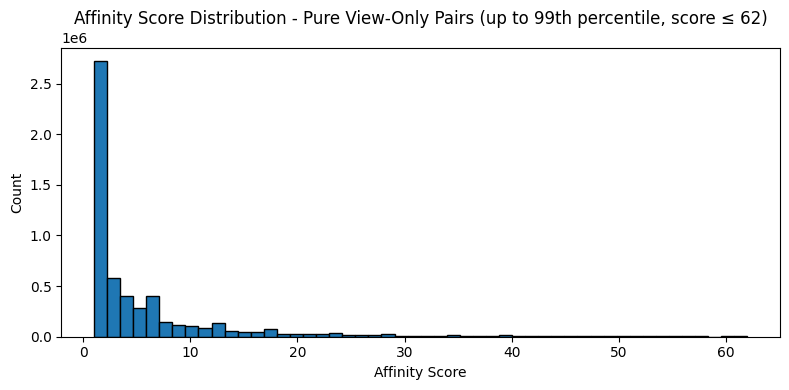

In [15]:
p99_view_only = view_only['affinity_score'].quantile(0.99)

plt.figure(figsize=(8, 4))
plt.hist(view_only[view_only['affinity_score'] <= p99_view_only]['affinity_score'], 
         bins=50, edgecolor='black')
plt.title(f'Affinity Score Distribution - Pure View-Only Pairs (up to 99th percentile, score ≤ {p99_view_only:.0f})')
plt.xlabel('Affinity Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

* No natural break point that seems like it can be an obvious cutoff for an upper threshold

#### Deciding on an upper affinity threshold
During exploratory analysis, extreme outliers were identified (user-category pairs with very high affinity scores driven entirely by views). Many approaches were considered to handle these:  
* Hard cutoff for pure view-only pairs above a score threshold
* Conversion proportion filter (require a minimum proportion of the score to come from carts or purchases)
* Minimum conversion activity requirement (at least 1 cart or purchase)
* Hybrid proportion + score cutoff

All options were rejected for the following reasons:
* **Arbitrary parameter choices** - the distribution of pure view-only affinity scores shows no natural break point. Any threshold chosen would be arbitrary and hard to justify
* **Cosine similarity is magnitude independent** - the similarity matrix is computed using cosine similarity, which measures the angle between vectors rather than their magnitude. Extreme values don't distort the similarity matrix.
* **Impact is isolated** - extreme scores will only affect the recommendation score calculation for that specific user. Because all their predicted scores are inflated proportionally, the relative ranking of their recommendations remains correct. Other users' recommendations are completely unaffected
* **Too aggressive alternatives** - requiring at least one cart or purchase from every pair would remove 83.81% of the dataset, making the cold start problem worse.

---

I decided that **no upper affinity threshold or filtering is applied**.
> Note: In a production system, bot detection or session analysis could be used to identify and remove abnormal view-only behavior. This is proposed as future work.

#### Deciding on a minimum affinity threshold
The affinity score was calculated by summing the weighted counts of views, cart adds, and purchases of a user in a particular item category.  
* Views = 1x
* Carts = 3x
* Purchased = 5x

In order to determine a minimum affinity threshold I have to think about what an affinity score means according to these weights:  
* A score of 2 = 2 views (weak signal)
* score of 3 = either 3 views or 1 cart addition
* score of 4 = 4 views or 1 cart + 1 view
* score of 5 = either 5 views, 1 cart + 2 views, or just 1 purchase

---

A score of 5 is the minimum score a single purchase can produce. With a threshold of 5, we keep all interactions that include at least one purchase, at least one cart addition with some views, or five or more  views. Below a score of 5, the signal may be too weak to represent genuine interest and is treated as noise.  
I decided to set a **minimum affinity threshold of 5**  
> Note: setting this threshold removes roughly 50% of user-category pairs, which worsens the "cold start problem" for users with very thin interaction histories. This is acknowledged as a limitation of this approach. 

### 1.3 Categories Per User
* I look at how many categories each user interacts with after applying the minimum affinity threshold of 5
* This tells me how sparse the interaction matrix will be

In [16]:
# Apply minimum affinity threshold
affinity_filtered = affinity_df[affinity_df['affinity_score'] >= 5]

# Count categories per user
cats_per_user = affinity_filtered.groupby('user_id')['main_category'].count()

print('--- Categories per user (after threshold) ---')
print(cats_per_user.describe().round(3))
print(f'\nUsers with only 1 category: {(cats_per_user == 1).sum():,}')
print(f'Users with 2 categories: {(cats_per_user == 2).sum():,}')
print(f'Users with 3+ categories: {(cats_per_user >= 3).sum():,}')
print(f'\nTotal users before threshold: {affinity_df["user_id"].nunique():,}')
print(f'Total users after threshold: {affinity_filtered["user_id"].nunique():,}')
print(f'Users lost to threshold: {affinity_df["user_id"].nunique() - affinity_filtered["user_id"].nunique():,}')

--- Categories per user (after threshold) ---
count    2227793.000
mean           1.363
std            0.738
min            1.000
25%            1.000
50%            1.000
75%            2.000
max           11.000
Name: main_category, dtype: float64

Users with only 1 category: 1,660,601
Users with 2 categories: 399,584
Users with 3+ categories: 167,608

Total users before threshold: 4,300,482
Total users after threshold: 2,227,793
Users lost to threshold: 2,072,689


* After applying the min affinity threshold of 5, 2227793 users remain out of the original 4300482 (48% of users had no interactions strong enough to be a meaningful)
* 74% of remaining users interact with only 1 category, confirming that sparse interaction histories are the norm in this dataset.
* Only 7.53% of users interact with 3 or more categories. these are the users 
where collaborative filtering will perform best

User who interacts with 11/13 categories:

In [17]:
user_max = affinity_filtered[affinity_filtered['user_id'] == cats_per_user.idxmax()]
print(user_max)

event_type    user_id main_category  cat_carts  cat_purchases  cat_views  \
1710989     519367815   accessories          1              0         68   
1710990     519367815       apparel          0              0         20   
1710991     519367815    appliances          7              0         83   
1710992     519367815          auto          0              0          7   
1710993     519367815     computers          4              1         92   
1710994     519367815  construction          1              0         39   
1710996     519367815   electronics          2              0        114   
1710997     519367815     furniture          0              0         71   
1710998     519367815          kids          0              0          6   
1710999     519367815         sport          0              0          6   
1711000     519367815    stationery          1              1         10   

event_type  affinity_score  
1710989                 71  
1710990                 20  


The user with the broadest interaction history (user 519367815) interacts with 
11 out of 13 categories, with the strongest affinity in:
* electronics (120)
* computers (109)
* and appliances (104)

all tech-related categories, which makes sense

* This user is used as the worked example in section 4.2

In [18]:
def format_pct(x):
    if x >= 0.01:
        return f'{x:.2f}%'
    elif x >= 0.001:
        return f'{x:.4f}%'
    else:
        return f'{x:.6f}%'

In [19]:
category_counts = cats_per_user.value_counts().sort_index()
total_users = len(cats_per_user)

summary_table = pd.DataFrame({
    'Number of Categories': category_counts.index,
    'Number of Users': category_counts.values,
    'Percentage of Users': (category_counts.values / total_users * 100).round(6)
})

summary_table['Percentage of Users'] = summary_table['Percentage of Users'].map(format_pct)
summary_table = summary_table.reset_index(drop=True)

print(summary_table.to_string(index=False))

 Number of Categories  Number of Users Percentage of Users
                    1          1660601              74.54%
                    2           399584              17.94%
                    3           115912               5.20%
                    4            35577               1.60%
                    5            11299               0.51%
                    6             3400               0.15%
                    7             1070               0.05%
                    8              257               0.01%
                    9               83             0.0037%
                   10                9           0.000404%
                   11                1           0.000045%


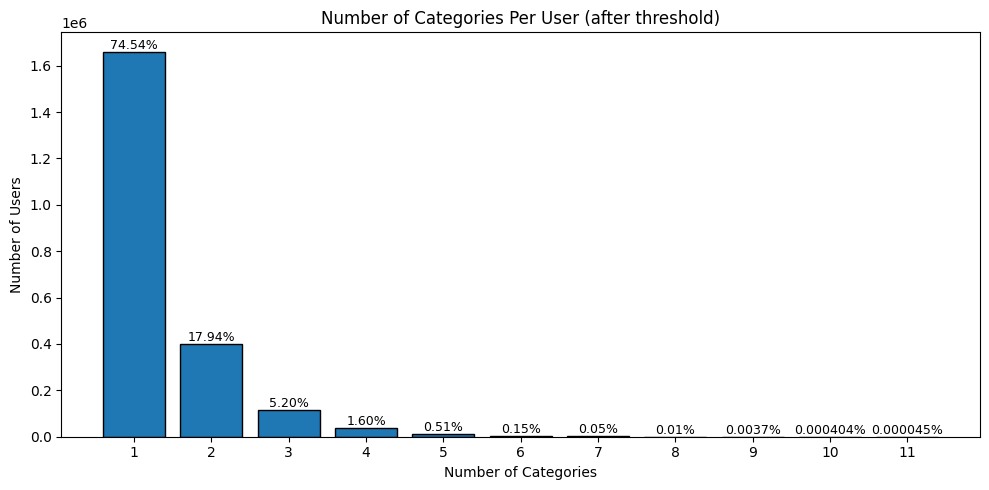

In [20]:
# Bar chart using same data
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(summary_table['Number of Categories'], 
              summary_table['Number of Users'], 
              edgecolor='black')

# Add percentage labels from summary table
for bar, pct in zip(bars, summary_table['Percentage of Users']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            pct, ha='center', va='bottom', fontsize=9)

ax.set_title('Number of Categories Per User (after threshold)')
ax.set_xlabel('Number of Categories')
ax.set_ylabel('Number of Users')
ax.set_xticks(range(1, 12))
plt.tight_layout()
plt.show()

#### 1.3 Observations/Notes
* Single-category users are kept in the interaction matrix as they still contribute to category-category similarity computation, and can still receive recommendations based on categories similar to their one known preference
* These findings reinforce the cold start problem: the majority of users do not have rich enough interaction histories for collaborative filtering to work effectively. For these users, falling back to globally popular category recommendations is the most reasonable approach

---


### 1.4 Category Popularity
* I examine how many users interact with each of the 13 categories after applying the minimum affinity threshold.
* This will reveal any popularity imbalance between categories (a known limitation of cosine similarity discussed in the methodology)

In [21]:
cat_popularity = (
    affinity_filtered.groupby('main_category')['user_id']
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'user_id': 'n_users'})
)

cat_popularity['percentage'] = (cat_popularity['n_users'] / affinity_filtered['user_id'].nunique() * 100).round(2)

print(cat_popularity.to_string(index=False))

main_category  n_users  percentage
  electronics  1572195       70.57
   appliances   554841       24.91
    computers   237891       10.68
      apparel   208769        9.37
    furniture   154408        6.93
         auto   110908        4.98
 construction    81366        3.65
         kids    60965        2.74
  accessories    29568        1.33
        sport    21101        0.95
     medicine     2315        0.10
 country_yard     1625        0.07
   stationery     1150        0.05


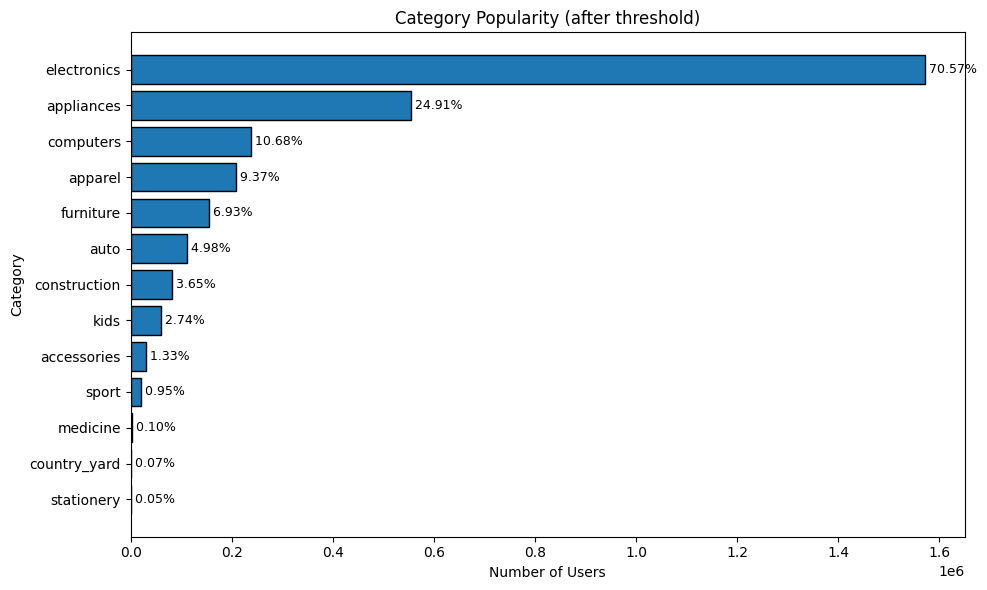

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(cat_popularity['main_category'], 
               cat_popularity['n_users'],
               edgecolor='black')

# Add percentage labels at the end of each bar
for bar, pct in zip(bars, cat_popularity['percentage']):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
            f' {pct:.2f}%', ha='left', va='center', fontsize=9)

ax.set_title('Category Popularity (after threshold)')
ax.set_xlabel('Number of Users')
ax.set_ylabel('Category')
ax.invert_yaxis() # most popular at top
plt.tight_layout()
plt.show()

#### 1.4 Observations
* Electronics is by far the most popular category, with 70.57% of all users interacting with it; more than double the second most popular category (appliances at 24.91%)
* There is a steep drop-off in popularity: the bottom 3 categories (medicine, country_yard, stationery) each have less than 0.1% of users
* This popularity imbalance is a known limitation of cosine similarity: two users with different tastes may appear similar just because they both have a high electronics score
* The bottom 3 categories have so few users that their similarity scores will be unreliable (acknowledged as a limitation)

---

## 2. Data Preparation
In this section, I prepare the data for the collaborative filtering model. This 
involves:
* building the user-category interaction matrix
* and splitting the data using a leave-one-out approach into training and test sets.

### 2.1 Sampling Users (edited)

> Initially a sample of 50,000 users was planned to verify the pipeline before 
scaling up. However, given that the affinity dataset only has 13 categories, 
the full filtered dataset of 2,227,793 users computed quickly enough that 
sampling was not necessary. The full dataset is used throughout this notebook.
A random seed is still defined in the constants for reproducibility of any 
other random operations later in the notebook.

In [23]:
sampled_df = affinity_filtered.copy()

print(f'Total users: {sampled_df["user_id"].nunique():,}')
print(f'Total rows: {len(sampled_df):,}')
print(f'Categories: {sampled_df["main_category"].nunique()}')

Total users: 2,227,793
Total rows: 3,037,102
Categories: 13


### 2.2 Building the User-Category Interaction Matrix

The affinity data is currently in long format (one row per user-category pair). 
For collaborative filtering, we need to reshape this into a wide format matrix 
where:
* each row is a user
* each column is a category
* and each cell contains the affinity score.
This is the user-category interaction matrix that the model operates on.

Users who did not interact with a category have no row in the long-format data, so missing cells are filled with 0, representing no affinity.

In [24]:
# Build user-category interaction matrix
interaction_matrix = sampled_df.pivot_table(
    index='user_id',
    columns='main_category',
    values='affinity_score',
    aggfunc='sum',
    fill_value=0
)

print(f'Matrix shape: {interaction_matrix.shape}')
print(f'Users: {interaction_matrix.shape[0]:,}')
print(f'Categories: {interaction_matrix.shape[1]}')
print(f'\nFirst 5 rows:')
print(interaction_matrix.head())

Matrix shape: (2227793, 13)
Users: 2,227,793
Categories: 13

First 5 rows:
main_category  accessories  apparel  appliances  auto  computers  \
user_id                                                            
29515875                 0        0           0     0          0   
31198833                 0        0           0     0          0   
62336140                 0       19           0     0          0   
74383042                 0        0           0     0         13   
94566147                 0        0           0     0          0   

main_category  construction  country_yard  electronics  furniture  kids  \
user_id                                                                   
29515875                  0             0            5          6     0   
31198833                  0             0           18          0     0   
62336140                  0             0            0          0     0   
74383042                  0             0            0          0     0  

#### 2.2 Observations
* The interaction matrix has 2,227,793. One row per user, one column per category
* Most cells are 0 — consistent with 74.54% of users interacting with only 1 category
* Missing values are filled with 0, representing no affinity between that user and category
* The `aggfunc='sum'` parameter is specified explicitly — summing is the correct behavior if there were duplicate user-category rows

### 2.3 Train/Test Split

A **leave-one-out** approach is used: for each user, their highest affinity category is held out as the test item and the model is evaluated on whether it recommends that category. 

Users with only 1 category are excluded from evaluation as they have no remaining training signal after the holdout.

> Since the affinity dataset was aggregated across both months into a single score per user-category pair, a temporal split is not directly feasible without recomputing affinity scores from the raw event data (requires a lot of resources and time)

In [25]:
# Identify users with more than 1 category (eligible for evaluation)
multi_cat_users = cats_per_user[cats_per_user > 1].index

print(f'Users with 2+ categories (eligible for evaluation): {len(multi_cat_users):,}')
print(f'Users with 1 category (excluded from evaluation): {(cats_per_user == 1).sum():,}')
print(f'Percentage eligible for evaluation: {len(multi_cat_users) / len(cats_per_user) * 100:.2f}%')

Users with 2+ categories (eligible for evaluation): 567,192
Users with 1 category (excluded from evaluation): 1,660,601
Percentage eligible for evaluation: 25.46%


#### Build leave-one-out split:

In [26]:
# For each eligible user, hold out their highest affinity category
loo_test = (
    sampled_df[sampled_df['user_id'].isin(multi_cat_users)]
    .groupby('user_id')
    .apply(lambda x: x.loc[x['affinity_score'].idxmax(), 'main_category'], include_groups=False)
    .reset_index()
    .rename(columns={0: 'held_out_category'})
)

# Training data — all interactions except the held out category per user
loo_train = sampled_df.merge(
    loo_test,
    on='user_id',
    how='left'
)
loo_train = loo_train[
    # keep row if user had no held out category (single category) or 
    (loo_train['held_out_category'].isna()) |
    (loo_train['main_category'] != loo_train['held_out_category'])
].drop(columns='held_out_category')

print(f'Test set  — users: {loo_test["user_id"].nunique():,}')
print(f'Test set  — rows: {len(loo_test):,}')
print(f'Train set — users: {loo_train["user_id"].nunique():,}')
print(f'Train set — rows: {len(loo_train):,}')
print(f'\nSample of test set:')
print(loo_test.head())

Test set  — users: 567,192
Test set  — rows: 567,192
Train set — users: 2,227,793
Train set — rows: 2,469,910

Sample of test set:
     user_id held_out_category
0   29515875         furniture
1  128968633       electronics
2  197647707        appliances
3  228192583        appliances
4  237973968        appliances


In [27]:
pct_eligible = len(multi_cat_users) / len(cats_per_user) * 100
pct_excluded = (cats_per_user == 1).sum() / len(cats_per_user) * 100

print(f'\nPercentage eligible for evaluation : {pct_eligible:.2f}%')
print(f'Percentage excluded from evaluation: {pct_excluded:.2f}%')


Percentage eligible for evaluation : 25.46%
Percentage excluded from evaluation: 74.54%


In [28]:
# Save leave-one-out test set for use in notebook 08
loo_test.to_parquet(f'{OUTPUT_DIR}/loo_test.parquet')
print(f'LOO test set saved: {loo_test.shape}')

LOO test set saved: (567192, 2)


#### 2.3 Observations
* 567,192 users (25.46%) are eligible for evaluation — these are users with 2+ categories after filtering
* 1,660,601 users (74.54%) are excluded from evaluation as they have only 1 
category. Holding out their one category would leave no training signal
* The test set contains exactly one held-out category per eligible user: their 
highest affinity category
* The test set has exactly one held-out category per eligible user (their 
highest affinity category)
* The difference between the full dataset rows (3,037,102) and training rows 
(2,469,910) is exactly 567,192, confirming one row was correctly removed per 
eligible user

---

## 3. Category-Category Similarity Matrix

* Transpose the training interaction matrix so categories become rows
* Compute cosine similarity between every pair of categories.
* The result is a 13×13 matrix where each cell represents how similar two categories are based purely on shared user behavior (not content or description).

The similarity matrix is saved for reuse in notebook 08.

### 3.1 Computing the Similarity Matrix

In [29]:
# Build training interaction matrix from loo_train
train_matrix = loo_train.pivot_table(
    index='user_id',
    columns='main_category',
    values='affinity_score',
    aggfunc='sum',
    fill_value=0
)

print(f'Training matrix shape: {train_matrix.shape}')

Training matrix shape: (2227793, 13)


#### Compute similarity matrix:

In [30]:
# Transpose so categories are rows
category_matrix = train_matrix.T

# Compute cosine similarity between all category pairs
similarity_matrix = pd.DataFrame(
    cosine_similarity(category_matrix),
    index=category_matrix.index,
    columns=category_matrix.index
)

print(f'Similarity matrix shape: {similarity_matrix.shape}')
print(f'\nSimilarity matrix:')
print(similarity_matrix.round(3))

Similarity matrix shape: (13, 13)

Similarity matrix:
main_category  accessories  apparel  appliances   auto  computers  \
main_category                                                       
accessories          1.000    0.084       0.051  0.038      0.042   
apparel              0.084    1.000       0.061  0.038      0.041   
appliances           0.051    0.061       1.000  0.046      0.056   
auto                 0.038    0.038       0.046  1.000      0.050   
computers            0.042    0.041       0.056  0.050      1.000   
construction         0.040    0.050       0.058  0.058      0.043   
country_yard         0.012    0.010       0.010  0.012      0.007   
electronics          0.028    0.025       0.022  0.027      0.019   
furniture            0.059    0.070       0.066  0.028      0.037   
kids                 0.037    0.048       0.050  0.018      0.026   
medicine             0.027    0.018       0.021  0.008      0.015   
sport                0.028    0.037       0.030  

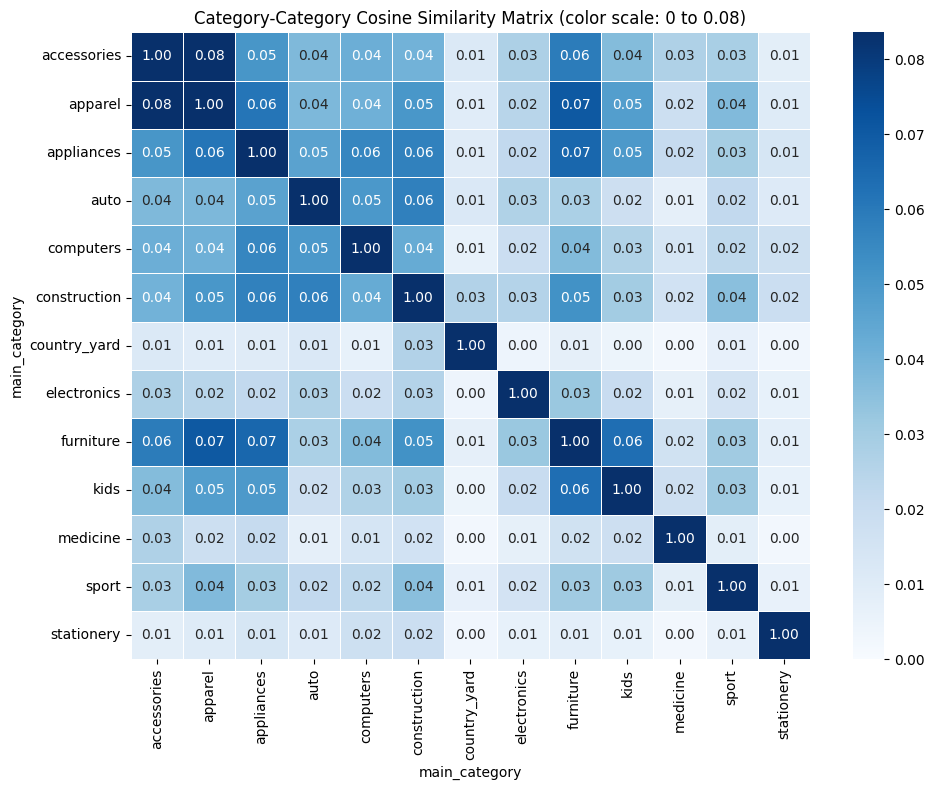

In [31]:
# Get max non-diagonal value for color scaling
mask_diagonal = np.eye(len(similarity_matrix), dtype=bool)
max_val = similarity_matrix.values[~mask_diagonal].max()

plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=0,
    vmax=max_val,
    linewidths=0.5
)
plt.title(f'Category-Category Cosine Similarity Matrix (color scale: 0 to {max_val:.2f})')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/similarity_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

* The diagonal is all 1.0 as expected (every category is perfectly similar 
to itself)
* Overall similarity scores are very low, with most values below 0.08. This shows the sparse nature of the dataset
* The color scale is adjusted to the actual data range (0 to 0.08) rather than 
the full cosine similarity range (0 to 1) to make differences between cells 
visible. The title explicitly states this to avoid misleading the reader

In [32]:
# Extract non-diagonal similarity values and rank them
similarity_pairs = []

for i in range(len(similarity_matrix)):
    for j in range(i+1, len(similarity_matrix)):  # upper triangle only, avoid duplicates
        cat1 = similarity_matrix.index[i]
        cat2 = similarity_matrix.columns[j]
        score = similarity_matrix.iloc[i, j]
        similarity_pairs.append((cat1, cat2, score))

similarity_pairs_df = pd.DataFrame(
    similarity_pairs,
    columns=['category_1', 'category_2', 'similarity_score']
).sort_values('similarity_score', ascending=False).reset_index(drop=True)

print('--- Top 10 most similar category pairs ---')
print(similarity_pairs_df.head(10).to_string(index=False))

print('\n--- Top 10 least similar category pairs ---')
print(similarity_pairs_df.tail(10).to_string(index=False))

--- Top 10 most similar category pairs ---
  category_1   category_2  similarity_score
 accessories      apparel          0.083556
     apparel    furniture          0.070207
  appliances    furniture          0.065870
   furniture         kids          0.063466
     apparel   appliances          0.061335
 accessories    furniture          0.059289
        auto construction          0.058084
  appliances construction          0.057707
  appliances    computers          0.056109
construction    furniture          0.052039

--- Top 10 least similar category pairs ---
  category_1   category_2  similarity_score
country_yard        sport          0.007012
 electronics   stationery          0.006672
        kids   stationery          0.006570
   computers country_yard          0.006555
       sport   stationery          0.006344
country_yard         kids          0.004768
country_yard  electronics          0.004466
country_yard   stationery          0.003083
    medicine   stationery       

#### Similarity Matrix Observations

Most similar pairs:
* **Accessories and apparel** have the highest similarity (0.084) — the same type of shopper may tend to browse both fashion-related categories
* **Furniture** appears in 4 of the top 10 most similar pairs, suggesting furniture shoppers tend to be broad browsers across multiple categories
* **Auto and construction** (0.058) appear together, likely reflecting a similar DIY/home improvement profile

Least similar pairs:
* **Country_yard, medicine, and stationery have near-zero similarity with 
everything** — consistent with section 1.4 where these categories had less than 
0.1% of users.

In [33]:
print('--- Average similarity score per category (excluding self) ---')
avg_sim = {}
for cat in similarity_matrix.index:
    other_cats = similarity_matrix[cat].drop(cat)
    avg_sim[cat] = other_cats.mean()

avg_sim_df = pd.DataFrame.from_dict(avg_sim, orient='index', columns=['avg_similarity'])
avg_sim_df = avg_sim_df.sort_values('avg_similarity', ascending=False).round(4)
print(avg_sim_df.to_string())

--- Average similarity score per category (excluding self) ---
              avg_similarity
apparel               0.0411
appliances            0.0404
furniture             0.0392
construction          0.0378
accessories           0.0378
computers             0.0313
auto                  0.0296
kids                  0.0294
sport                 0.0229
electronics           0.0193
medicine              0.0133
stationery            0.0095
country_yard          0.0089


* **Electronics has very low average similarity** (0.0193) despite being the most popular category
* Its ubiquity means it does not discriminate between user types

### 3.2 Shrinkage Weighting
* The raw cosine similarity matrix treats all similarity scores equally, regardless of how many users they are based on.
* To address this, I apply shrinkage weighting: adjusting each similarity score by a confidence multiplier based on the number of shared users between each category pair.
* The adjusted similarity matrix will be used in place of the raw similarity matrix for generating recommendations and will be saved for reuse in notebook 08.

In [34]:
# Compute number of shared users between each category pair
# A user "shares" two categories if they have a non-zero score in both
binary_matrix = (train_matrix > 0).astype(int)

shared_users = pd.DataFrame(
    binary_matrix.T.dot(binary_matrix),
    index=train_matrix.columns,
    columns=train_matrix.columns
)

# Extract non-diagonal pairs
shared_pairs = []
for i in range(len(shared_users)):
    for j in range(i+1, len(shared_users)):
        cat1 = shared_users.index[i]
        cat2 = shared_users.columns[j]
        n = shared_users.iloc[i, j]
        shared_pairs.append((cat1, cat2, n))

shared_pairs_df = pd.DataFrame(
    shared_pairs,
    columns=['category_1', 'category_2', 'shared_users']
).sort_values('shared_users', ascending=False).reset_index(drop=True)

print('--- Top 10 category pairs by shared users ---')
print(shared_pairs_df.head(10).to_string(index=False))

print('\n--- Bottom 10 category pairs by shared users ---')
print(shared_pairs_df.tail(10).to_string(index=False))

print('\n--- Max shared users per sparse category ---')
sparse_cats = ['country_yard', 'medicine', 'stationery']
for cat in sparse_cats:
    max_shared = shared_pairs_df[
        (shared_pairs_df['category_1'] == cat) | 
        (shared_pairs_df['category_2'] == cat)
    ]['shared_users'].max()
    print(f'{cat:15} : {max_shared:,} max shared users')

--- Top 10 category pairs by shared users ---
 category_1  category_2  shared_users
 appliances electronics         25553
    apparel  appliances         21816
 appliances   computers         20115
    apparel electronics         19869
electronics   furniture         19318
 appliances   furniture         19105
  computers electronics         14702
    apparel   furniture         12737
    apparel   computers         11280
 appliances        auto         11198

--- Bottom 10 category pairs by shared users ---
  category_1   category_2  shared_users
country_yard         kids            72
    medicine        sport            72
 accessories country_yard            65
 accessories   stationery            64
        kids   stationery            62
country_yard        sport            52
       sport   stationery            28
    medicine   stationery             7
country_yard   stationery             5
country_yard     medicine             3

--- Max shared users per sparse category ---


#### Shared Users Observations
* The most well-supported category pairs are appliances/electronics (25,553 shared users), apparel/appliances (21,816), and appliances/computers (20,115):  these similarity scores are based on strong evidence and can be trusted
* Country_yard, medicine, and stationery have very few shared users with any other category
* The bottom 10 pairs are almost entirely dominated by these three categories. The lowest being country_yard/medicine at only 3 shared users
* This confirms that similarity scores involving these three categories are unreliable and motivates shrinkage weighting

#### Comparing Shrinkage Factors

In [35]:
shrinkage_factors = [25, 50, 100]

# Get the truly sparse pairs (bottom 5) and well supported pairs (top 5)
truly_sparse = shared_pairs_df.tail(5).copy()
well_supported = shared_pairs_df.head(5).copy()

for factor in shrinkage_factors:
    confidence = shared_users / (shared_users + factor)
    adjusted = similarity_matrix * confidence
    
    for df, label in [(truly_sparse, 'Truly sparse pairs'), 
                      (well_supported, 'Well-supported pairs')]:
        df[f'adj_{factor}'] = df.apply(
            lambda r: round(adjusted.loc[r['category_1'], r['category_2']], 5), 
            axis=1
        )

# Add original similarity
for df in [truly_sparse, well_supported]:
    df['original'] = df.apply(
        lambda r: round(similarity_matrix.loc[r['category_1'], r['category_2']], 5),
        axis=1
    )

print('--- Truly sparse pairs (bottom 5 by shared users) ---')
print(truly_sparse[['category_1', 'category_2', 'shared_users', 
                     'original', 'adj_25', 'adj_50', 'adj_100']].to_string(index=False))

print('\n--- Well-supported pairs (top 5 by shared users) ---')
print(well_supported[['category_1', 'category_2', 'shared_users',
                       'original', 'adj_25', 'adj_50', 'adj_100']].to_string(index=False))

--- Truly sparse pairs (bottom 5 by shared users) ---
  category_1 category_2  shared_users  original  adj_25  adj_50  adj_100
country_yard      sport            52   0.00701 0.00474 0.00357  0.00240
       sport stationery            28   0.00634 0.00335 0.00228  0.00139
    medicine stationery             7   0.00257 0.00056 0.00032  0.00017
country_yard stationery             5   0.00308 0.00051 0.00028  0.00015
country_yard   medicine             3   0.00241 0.00026 0.00014  0.00007

--- Well-supported pairs (top 5 by shared users) ---
 category_1  category_2  shared_users  original  adj_25  adj_50  adj_100
 appliances electronics         25553   0.02193 0.02191 0.02188  0.02184
    apparel  appliances         21816   0.06134 0.06126 0.06119  0.06106
 appliances   computers         20115   0.05611 0.05604 0.05597  0.05583
    apparel electronics         19869   0.02466 0.02463 0.02460  0.02454
electronics   furniture         19318   0.03208 0.03204 0.03200  0.03192


#### Shrinkage Factor Comparison Observations
* All three factors have negligible effect on **well-supported pairs**: appliances/electronics (25,553 shared users) changes by less than 0.001 
across all factors, confirming that shrinkage does not distort reliable 
similarity scores
* All three factors significantly reduce truly **sparse pairs**: country_yard/medicine (3 shared users) drops from 0.00241 to 0.00026 (factor 25), 
0.00014 (factor 50), and 0.00007 (factor 100)
* **Factor 50 is chosen** as it reduces the noisiest pairs to near-zero while 
leaving well-supported pairs virtually unchanged.
* At exactly 50 shared users the confidence multiplier equals 0.5: a clear and interpretable cutoff point

In [36]:
# Apply shrinkage weighting with chosen factor
SHRINKAGE_FACTOR = 50

confidence = shared_users / (shared_users + SHRINKAGE_FACTOR)
adjusted_similarity = similarity_matrix * confidence

# Set diagonal back to 1.0 — a category is always perfectly similar to itself
np.fill_diagonal(adjusted_similarity.values, 1.0)

print(f'Shrinkage factor: {SHRINKAGE_FACTOR}')
print(f'\nAdjusted similarity matrix:')
print(adjusted_similarity.round(4))

Shrinkage factor: 50

Adjusted similarity matrix:
main_category  accessories  apparel  appliances    auto  computers  \
main_category                                                        
accessories         1.0000   0.0828      0.0504  0.0370     0.0411   
apparel             0.0828   1.0000      0.0612  0.0377     0.0409   
appliances          0.0504   0.0612      1.0000  0.0461     0.0560   
auto                0.0370   0.0377      0.0461  1.0000     0.0494   
computers           0.0411   0.0409      0.0560  0.0494     1.0000   
construction        0.0395   0.0500      0.0575  0.0576     0.0424   
country_yard        0.0067   0.0076      0.0090  0.0096     0.0049   
electronics         0.0273   0.0246      0.0219  0.0266     0.0188   
furniture           0.0584   0.0699      0.0657  0.0277     0.0368   
kids                0.0357   0.0475      0.0493  0.0176     0.0261   
medicine            0.0190   0.0157      0.0193  0.0052     0.0121   
sport               0.0267   0.0367     

In [37]:
# Compare original vs adjusted similarity for all pairs
comparison_pairs = shared_pairs_df.copy()
comparison_pairs['original'] = comparison_pairs.apply(
    lambda r: round(similarity_matrix.loc[r['category_1'], r['category_2']], 5), axis=1
)
comparison_pairs['adjusted'] = comparison_pairs.apply(
    lambda r: round(adjusted_similarity.loc[r['category_1'], r['category_2']], 5), axis=1
)
comparison_pairs['change'] = (comparison_pairs['adjusted'] - comparison_pairs['original']).round(5)
comparison_pairs['pct_change'] = ((comparison_pairs['change'] / comparison_pairs['original']) * 100).round(1)

print('--- Top 10 most similar pairs (after shrinkage) ---')
print(comparison_pairs.sort_values('adjusted', ascending=False).head(10).to_string(index=False))

print('\n--- Most affected pairs (largest % change) ---')
print(comparison_pairs.sort_values('pct_change').head(10).to_string(index=False))

print('\n--- Least affected pairs (smallest % change) ---')
print(comparison_pairs.sort_values('pct_change').tail(10).to_string(index=False))

--- Top 10 most similar pairs (after shrinkage) ---
  category_1   category_2  shared_users  original  adjusted   change  pct_change
 accessories      apparel          5210   0.08356   0.08276 -0.00080        -1.0
     apparel    furniture         12737   0.07021   0.06993 -0.00028        -0.4
  appliances    furniture         19105   0.06587   0.06570 -0.00017        -0.3
   furniture         kids          5865   0.06347   0.06293 -0.00054        -0.9
     apparel   appliances         21816   0.06134   0.06119 -0.00015        -0.2
 accessories    furniture          3401   0.05929   0.05843 -0.00086        -1.5
        auto construction          5448   0.05808   0.05756 -0.00052        -0.9
  appliances construction         11186   0.05771   0.05745 -0.00026        -0.5
  appliances    computers         20115   0.05611   0.05597 -0.00014        -0.2
construction    furniture          5776   0.05204   0.05159 -0.00045        -0.9

--- Most affected pairs (largest % change) ---
  categor

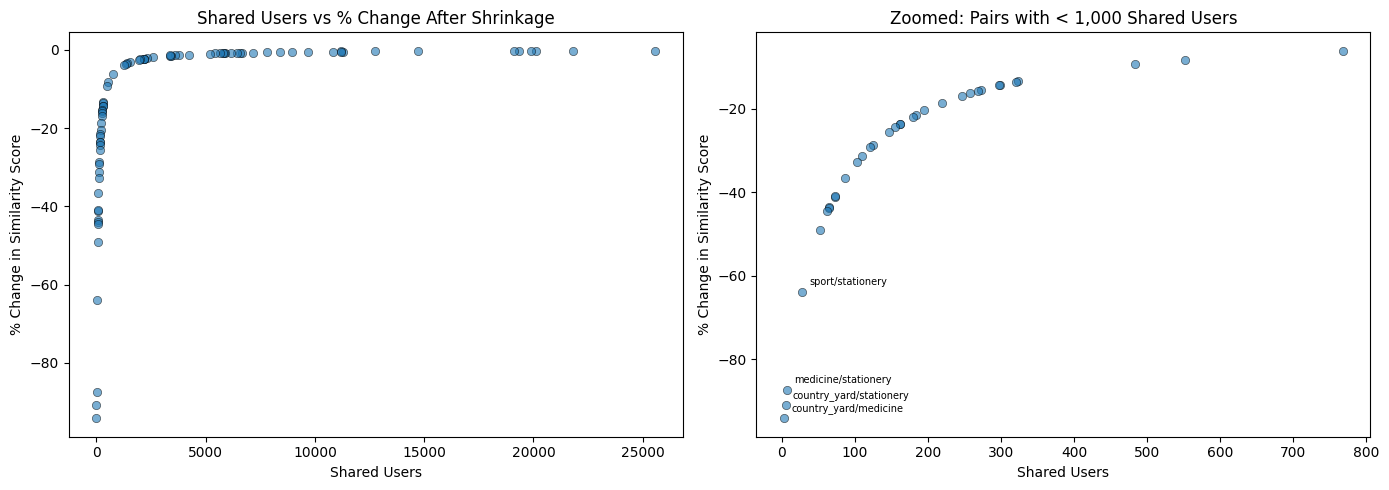

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot — shared users vs % change
axes[0].scatter(comparison_pairs['shared_users'], 
                comparison_pairs['pct_change'],
                alpha=0.6, edgecolors='black', linewidths=0.5)
axes[0].set_title('Shared Users vs % Change After Shrinkage')
axes[0].set_xlabel('Shared Users')
axes[0].set_ylabel('% Change in Similarity Score')

# Right plot — zoomed in to pairs with fewer than 1000 shared users
# where the interesting variation actually is
zoomed = comparison_pairs[comparison_pairs['shared_users'] < 1000]
axes[1].scatter(zoomed['shared_users'], 
                zoomed['pct_change'],
                alpha=0.6, edgecolors='black', linewidths=0.5)

# Label the most affected points
for _, row in zoomed[zoomed['pct_change'] < -50].iterrows():
    axes[1].annotate(
        f"{row['category_1']}/{row['category_2']}",
        (row['shared_users'], row['pct_change']),
        fontsize=7, xytext=(5, 5), textcoords='offset points'
    )

axes[1].set_title('Zoomed: Pairs with < 1,000 Shared Users')
axes[1].set_xlabel('Shared Users')
axes[1].set_ylabel('% Change in Similarity Score')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/shrinkage_effect.png', dpi=300, bbox_inches='tight')
plt.show()

#### Shrinkage Weighting Observations
* The scatter plots confirm that shrinkage is working as intended, pairs with fewer shared users are penalized more heavily, while pairs with many shared users are barely affected
* **Most penalized**: country_yard/medicine (3 shared users,-94.2%), country_yard/stationery (5 shared users, -90.9%), and medicine/stationery (7 shared users, -87.5%) —> essentially zero, no influence on recommendations
* **Least affected**: all top 10 pairs by less than 0.5%
* The ranking of the top 10 most similar pairs is unchanged after shrinkage

In [39]:
# Save adjusted similarity matrix for use in recommendations and notebook 08
adjusted_similarity.to_parquet(f'{OUTPUT_DIR}/adjusted_similarity_matrix.parquet')
print(f'Adjusted similarity matrix saved to {OUTPUT_DIR}/adjusted_similarity_matrix.parquet')

Adjusted similarity matrix saved to /kaggle/working/adjusted_similarity_matrix.parquet


---

## 4. Generating Recommendations

* Using the adjusted similarity matrix from section 3.2, I generate top-K category recommendations for each user in the training set.
* For each user, predicted affinity scores are computed for categories they have not interacted with using a weighted sum of their known affinity scores and the similarity between their known categories and each unseen category.
* The top K categories by predicted score are returned as recommendations.

> Only users with at least one interaction in the training set are eligible for 
recommendations. Users with only 1 category will receive recommendations based 
on that single category's similarity scores.

### 4.1 Recommendation Function

The recommendation function takes a single user's affinity vector and the 
adjusted similarity matrix and returns their top K recommended categories.

In [40]:
def get_recommendations(user_id, train_matrix, similarity_matrix, k=K):
    # Get user's affinity vector from training matrix
    user_vector = train_matrix.loc[user_id]
    
    # Identify categories the user has and hasn't interacted with
    seen = user_vector[user_vector > 0].index.tolist()
    unseen = user_vector[user_vector == 0].index.tolist()
    
    # If user has seen all categories, nothing to recommend
    if not unseen:
        return []
    
    # Compute predicted score for each unseen category
    predicted_scores = {}
    for cat in unseen:
        score = sum(
            user_vector[seen_cat] * similarity_matrix.loc[seen_cat, cat]
            for seen_cat in seen
        )
        predicted_scores[cat] = score
    
    # Rank by predicted score and return top K
    recommendations = sorted(
        predicted_scores.items(), 
        key=lambda x: x[1], 
        reverse=True
    )[:k]
    
    return recommendations

### 4.2 Worked Example
* Before running recommendations for all users, I walk through a single user 
step by step to verify the function works correctly and to demonstrate exactly 
how recommendations are generated.

* I use user 519367815, the user with the broadest interaction history (11 out 
of 13 categories) identified in section 1.3. This user is a good example 
because their rich interaction history makes the recommendation logic easy to 
follow and interpret.

In [41]:
example_user = cats_per_user.idxmax()

# Show user's training profile
user_vector = train_matrix.loc[example_user]
seen = user_vector[user_vector > 0].sort_values(ascending=False)
unseen = user_vector[user_vector == 0].index.tolist()

print(f'--- User {example_user} training profile ---')
print(f'Seen categories ({len(seen)}):')
print(seen.to_string())
print(f'\nUnseen categories ({len(unseen)}): {unseen}')

--- User 519367815 training profile ---
Seen categories (10):
main_category
computers       109
appliances      104
furniture        71
accessories      71
construction     42
apparel          20
stationery       18
auto              7
kids              6
sport             6

Unseen categories (3): ['country_yard', 'electronics', 'medicine']


In [42]:
print(f'--- Predicted scores for unseen categories ---')
for cat in unseen:
    score = 0
    contributions = []
    for seen_cat in seen.index:
        sim = adjusted_similarity.loc[seen_cat, cat]
        contribution = seen[seen_cat] * sim
        score += contribution
        contributions.append((seen_cat, seen[seen_cat], round(sim, 4), round(contribution, 4)))
    
    print(f'\nCategory: {cat} | Predicted score: {round(score, 4)}')
    contrib_df = pd.DataFrame(
        contributions, 
        columns=['seen_category', 'affinity_score', 'similarity', 'contribution']
    ).sort_values('contribution', ascending=False)
    print(contrib_df.to_string(index=False))

--- Predicted scores for unseen categories ---

Category: country_yard | Predicted score: 3.5554
seen_category  affinity_score  similarity  contribution
   appliances             104      0.0090        0.9384
 construction              42      0.0221        0.9302
    computers             109      0.0049        0.5322
  accessories              71      0.0067        0.4791
    furniture              71      0.0058        0.4122
      apparel              20      0.0076        0.1530
         auto               7      0.0096        0.0670
        sport               6      0.0036        0.0214
         kids               6      0.0028        0.0169
   stationery              18      0.0003        0.0050

Category: electronics | Predicted score: 10.6073
seen_category  affinity_score  similarity  contribution
   appliances             104      0.0219        2.2759
    furniture              71      0.0320        2.2721
    computers             109      0.0188        2.0537
  accessories

In [43]:
recommendations = get_recommendations(example_user, train_matrix, adjusted_similarity, k=K)

print(f'--- Top {K} recommendations for user {example_user} ---')
rec_df = pd.DataFrame(recommendations, columns=['category', 'predicted_score'])
rec_df['predicted_score'] = rec_df['predicted_score'].round(4)
rec_df.index = rec_df.index + 1  # start ranking from 1
print(rec_df.to_string())

print(f'\n--- Held out test category ---')
held_out = loo_test[loo_test['user_id'] == example_user]['held_out_category'].values[0]
print(f'Held out category : {held_out}')
print(f'Correctly recommended : {held_out in [r[0] for r in recommendations]}')

--- Top 5 recommendations for user 519367815 ---
       category  predicted_score
1   electronics          10.6073
2      medicine           6.6768
3  country_yard           3.5554

--- Held out test category ---
Held out category : electronics
Correctly recommended : True


#### 4.2 Worked Example Observations
* The model correctly recommended electronics as the #1 recommendation (predicted score 10.61). Successfully recovering the held-out category
* Electronics scored highest because this user has strong affinity in categories most similar to electronics: appliance (104), computers (109), furniture (71)
* Only 3 recommendations were returned instead of 5 because this user has already interacted with 10 out of 13 categories, leaving only 3 unseen categories left to recommend from
* Country_yard received the lowest predicted score (3.56), which is consistent with its near-zero similarity scores across all categories

### 4.3 Recommendations for All Users

* I apply the recommendation function across all users in the training matrix
* Store the results in a recommendations table

In [44]:
# Vectorized recommendation generation using matrix multiplication
# predicted_scores = train_matrix @ adjusted_similarity
# This computes predicted scores for all users and all categories simultaneously

train_array = train_matrix.values
similarity_array = adjusted_similarity.values

# Matrix multiplication — each row is a user's predicted scores for all categories
predicted_scores = np.dot(train_array, similarity_array)

# Convert to dataframe
predicted_df = pd.DataFrame(
    predicted_scores,
    index=train_matrix.index,
    columns=train_matrix.columns
)

# Zero out categories the user has already interacted with
# We don't want to recommend things they've already seen
predicted_df[train_matrix > 0] = 0

print(f'Predicted scores matrix shape: {predicted_df.shape}')
print(f'\nSample predicted scores (first 5 users):')
print(predicted_df.head().round(4))

Predicted scores matrix shape: (2227793, 13)

Sample predicted scores (first 5 users):
main_category  accessories  apparel  appliances    auto  computers  \
user_id                                                              
29515875            0.1367   0.1230      0.1094  0.1330     0.0942   
31198833            0.4923   0.4428      0.3939  0.4790     0.3391   
62336140            1.5725   0.0000      1.1627  0.7157     0.7774   
74383042            0.5347   0.5319      0.7276  0.6426     0.0000   
94566147            0.6564   0.5904      0.5252  0.6386     0.4522   

main_category  construction  country_yard  electronics  furniture    kids  \
user_id                                                                     
29515875             0.1279        0.0193       0.0000     0.1600  0.0993   
31198833             0.4603        0.0696       0.0000     0.5760  0.3574   
62336140             0.9509        0.1453       0.4674     1.3287  0.9019   
74383042             0.5513        0.

* A 0.0 means either the user already interacted with that category (zeroed out) or there's no signal to predict from
* A higher number means the model thinks the user would be more interested in that category

In [45]:
print('Generating recommendations...')
# Extract top K recommendations per user
all_recommendations = []

# Get top K indices for each user
top_k_indices = np.argsort(predicted_scores, axis=1)[:, -K:][:, ::-1]
categories = train_matrix.columns.tolist()

for i, user_id in enumerate(train_matrix.index):
    for rank, cat_idx in enumerate(top_k_indices[i], start=1):
        score = predicted_scores[i, cat_idx]
        if score > 0:  # only include categories with positive predicted score
            all_recommendations.append((user_id, categories[cat_idx], round(score, 4), rank))

recommendations_df = pd.DataFrame(
    all_recommendations,
    columns=['user_id', 'recommended_category', 'predicted_score', 'rank']
)

print(f'Total recommendations generated : {len(recommendations_df):,}')
print(f'Users with recommendations      : {recommendations_df["user_id"].nunique():,}')
print(f'\nSample recommendations:')
print(recommendations_df.head(10).to_string(index=False))

Generating recommendations...
Total recommendations generated : 11,138,954
Users with recommendations      : 2,227,793

Sample recommendations:
 user_id recommended_category  predicted_score  rank
29515875            furniture           0.1600     1
29515875          accessories           0.1367     2
29515875                 auto           0.1330     3
29515875         construction           0.1279     4
29515875              apparel           0.1230     5
31198833            furniture           0.5760     1
31198833          accessories           0.4923     2
31198833                 auto           0.4790     3
31198833         construction           0.4603     4
31198833              apparel           0.4428     5


In [46]:
# Save recommendations
recommendations_df.to_parquet(f'{OUTPUT_DIR}/recommendations.parquet')
print(f'Recommendations saved to {OUTPUT_DIR}/recommendations.parquet')

Recommendations saved to /kaggle/working/recommendations.parquet


#### 4.3 Observations
* Recommendations were generated for all 2,227,793 users in the training set
* 11,138,954 total recommendations were generated, an average of 5 per user (consistent with K=5)
* Categories the user has already interacted with are zeroed out before ranking so they are never recommended
* Users with only 1 category receive recommendations based purely on that 
category's similarity scores — less personalized but still meaningful

---

## 5. Evaluation

* Evaluate the model using Recall@K on the leave-one-out test set.
* For each eligible user (those with 2+ categories), I check whether their held-out category appears in their top K recommendations.
* A random baseline is also computed to contextualize the results. a random recommender would correctly recommend the held-out category with a probability of K divided by the number of unseen categories per user.

> Edit Note: Precision@K is not used (though it was originally). With only one held-out item per user, Precision@K measures what fraction of K recommendations were correct. But since there is only one correct answer per user, precision is 1/K if the model got it right and 0 if not. Also Precision@K = Recall@K / K meaning that it will provide no additional information beyond Recall@K

### 5.1 Recall@K

In [47]:
# Merge recommendations with test set
eval_df = loo_test.merge(
    recommendations_df,
    on='user_id',
    how='left'
)

# For each user, check if held out category appears in their top K recommendations
eval_df['hit'] = eval_df['held_out_category'] == eval_df['recommended_category']

# Compute per-user hit (1 if held out category appears anywhere in top K, 0 if not)
user_hits = eval_df.groupby('user_id')['hit'].max().reset_index()
user_hits.columns = ['user_id', 'hit']

# Compute metrics
recall_at_k = user_hits['hit'].mean()
# precision_at_k = recall_at_k / K

print(f'--- Evaluation Results (K={K}) ---')
print(f'Eligible users evaluated : {len(user_hits):,}')
print(f'Recall@{K}               : {recall_at_k:.4f} ({recall_at_k*100:.2f}%)')
# print(f'Precision@{K}            : {precision_at_k:.4f} ({precision_at_k*100:.2f}%)')

--- Evaluation Results (K=5) ---
Eligible users evaluated : 567,192
Recall@5               : 0.3350 (33.50%)


* Model achieved Recall@5 of 33.50%
* On its own, this number is hard to interpret, so I calculate a random baseline to contextualize it: For each eligible user, what is the probability a random recommender would correctly recommend their held out category in K guesses?

In [48]:
# Compute random baseline

# Number of unseen categories per user at evaluation time
user_unseen_counts = (train_matrix.loc[loo_test['user_id']] == 0).sum(axis=1)

# Random baseline recall = K / number of unseen categories per user
random_baseline = (K / user_unseen_counts).mean()

print(f'--- Random Baseline (K={K}) ---')
print(f'Average unseen categories per user : {user_unseen_counts.mean():.2f}')
print(f'Random Baseline Recall@{K}         : {random_baseline:.4f} ({random_baseline*100:.2f}%)')
print(f'\n--- Model vs Random Baseline ---')
print(f'Model Recall@{K}    : {recall_at_k*100:.2f}%')
print(f'Random Recall@{K}   : {random_baseline*100:.2f}%')
print(f'Improvement        : {((recall_at_k - random_baseline) / random_baseline * 100):.2f}%')

--- Random Baseline (K=5) ---
Average unseen categories per user : 11.57
Random Baseline Recall@5         : 0.4345 (43.45%)

--- Model vs Random Baseline ---
Model Recall@5    : 33.50%
Random Recall@5   : 43.45%
Improvement        : -22.91%


* The random baseline Recall@5 is 43.45%
* the model scores 9.95 percentage points below random
* Before concluding the model is performing poorly, I need to understand *where* it is succeeding and failing

In [49]:
print('--- Held out category distribution ---')
print(loo_test['held_out_category'].value_counts())
print(f'\nPercentage with electronics held out: {(loo_test["held_out_category"] == "electronics").mean()*100:.2f}%')

--- Held out category distribution ---
held_out_category
electronics     265616
appliances      127923
computers        52707
apparel          38661
furniture        26824
auto             21974
construction     15672
kids              9997
accessories       4344
sport             2872
medicine           276
country_yard       196
stationery         130
Name: count, dtype: int64

Percentage with electronics held out: 46.83%


* 46.83% of eligible users have electronics as their held-out category (nearly half of all test cases)
* Electronics is the most popular category (70.57% of users), but has the lowest average similarity with all other categories due to its ubiquity
* If the model systematically fails on electronics, it will heavily drag down the overall recall

In [50]:
# Merge held out category into user hits
user_hits_detail = user_hits.merge(loo_test, on='user_id')

# Recall by held out category
recall_by_category = user_hits_detail.groupby('held_out_category')['hit'].agg(
    ['sum', 'count', 'mean']
).round(4)
recall_by_category.columns = ['hits', 'total', 'recall']
recall_by_category = recall_by_category.sort_values('recall', ascending=False)

print('--- Recall@5 by held out category ---')
print(recall_by_category.to_string())

--- Recall@5 by held out category ---
                    hits   total  recall
held_out_category                       
construction       15542   15672  0.9917
apparel            38003   38661  0.9830
accessories         4253    4344  0.9791
furniture          25587   26824  0.9539
auto               16649   21974  0.7577
appliances         69336  127923  0.5420
kids                4178    9997  0.4179
computers          14087   52707  0.2673
sport                144    2872  0.0501
electronics         2215  265616  0.0083
medicine               1     276  0.0036
country_yard           0     196  0.0000
stationery             0     130  0.0000


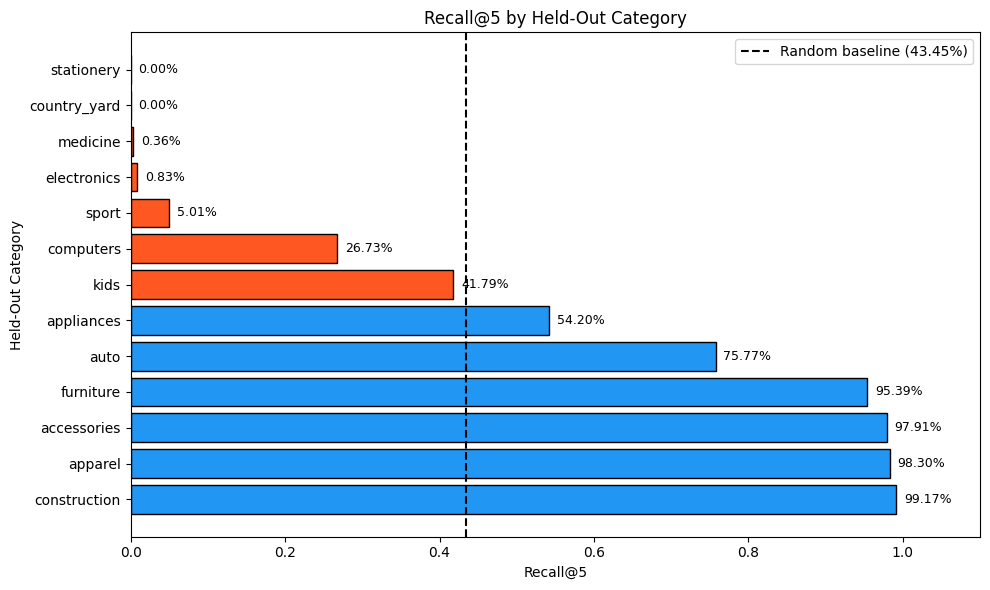

In [51]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2196F3' if r >= 0.4345 else '#FF5722' 
          for r in recall_by_category['recall']]

bars = ax.barh(
    recall_by_category.index,
    recall_by_category['recall'],
    color=colors,
    edgecolor='black'
)

# Add recall percentage labels
for bar, recall in zip(bars, recall_by_category['recall']):
    ax.text(bar.get_width() + 0.01, 
            bar.get_y() + bar.get_height() / 2,
            f'{recall*100:.2f}%',
            va='center', fontsize=9)

# Add random baseline line
ax.axvline(x=random_baseline, color='black', linestyle='--', linewidth=1.5,
           label=f'Random baseline ({random_baseline*100:.2f}%)')

ax.set_title(f'Recall@{K} by Held-Out Category')
ax.set_xlabel(f'Recall@{K}')
ax.set_ylabel('Held-Out Category')
ax.legend()
ax.set_xlim(0, 1.1)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/recall_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

* The per-category breakdown reveals the model is not uniformly bad; It has two distinct failure modes and one clear strength
* **Where it succeeds:** construction (99.17%), apparel (98.30%), accessories (97.91%), and furniture (95.39%) all far above the random baseline. These are mid-popularity categories with meaningful similarity scores
* **Failure mode 1 — popularity bias:** electronics recall is only 0.83% despite being the held-out category for 46.83% of users. Cosine similarity gives it near-zero scores with everything because almost everyone interacts with it
* **Failure mode 2 — sparse categories:** medicine (0.36%), country_yard (0.00%), and stationery (0.00%) fail because their similarity scores are near-zero even after shrinkage (there is not enough shared user signal)
* The overall recall of 33.50% is almost entirely dragged down by electronics being the held-out category for nearly half of all test users. For the categories where the model actually has a signal, it performs fairly well

In [52]:
# Recall excluding electronics and sparse categories
exclude_cats = ['electronics', 'medicine', 'country_yard', 'stationery']

filtered_recall = recall_by_category[
    ~recall_by_category.index.isin(exclude_cats)
]

filtered_recall_at_k = (
    filtered_recall['hits'].sum() / filtered_recall['total'].sum()
)

print(f'--- Recall@{K} excluding electronics and sparse categories ---')
print(f'Categories excluded : {exclude_cats}')
print(f'Users evaluated     : {filtered_recall["total"].sum():,}')
print(f'Recall@{K}          : {filtered_recall_at_k:.4f} ({filtered_recall_at_k*100:.2f}%)')
print(f'Random baseline     : {random_baseline*100:.2f}%')
print(f'Improvement over random: {((filtered_recall_at_k - random_baseline) / random_baseline * 100):.2f}%')

--- Recall@5 excluding electronics and sparse categories ---
Categories excluded : ['electronics', 'medicine', 'country_yard', 'stationery']
Users evaluated     : 300,974
Recall@5          : 0.6239 (62.39%)
Random baseline     : 43.45%
Improvement over random: 43.59%


* Excluding electronics and the 3 sparse categories, Recall@5 is 62.39% (43.59% better than random 43.45%)
* This confirms the model performs well for the 9 categories where there is enough interaction data
* The overall underperformance is explain by the two failure modes explain above, though there are way the model could be improved.

---

## 6. Limitations and Notes

### 6.1 Limitations and Future Improvements

Several decisions made in this notebook were constrained by data availability, computational feasibility, or scope. Below I talk about the key limitations and what could be done differently to improve the model.

**1. Category-level vs product-level recommendations**
* The model operates at the category level (13 categories), not the product level (190,000 products).
* I decided this to avoid sparsity and computational issues, but it comes at the cost of recommendation granularity.
* For example: the category-level recommendation of "electronics" is less useful to a real user than "this specific Samsung TV."
* Product-level CF would require sparse matrix implementations (e.g. `scipy.sparse`) and TF-IDF weighting

**2. Popularity bias in cosine similarity**
* Electronics being recommended at only 0.83% recall despite being the most interacted-with category -> cosine similarity cannot distinguish between genuinely similar categories and universally popular ones
* TF-IDF weighting would fix this by deflating popular categories

**3. Temporal split not feasible**
* A temporal split (October = train, November = test) would be a more realistic evaluation strategy, as it's more similar to real deployment conditions.
* It was not implemented because the affinity dataset was aggregated across both months into a single score per user-category pair.
* Would require recomputing affinity scores separately per month from the raw event data

**4. Leave-one-out design penalizes the most popular category**
* Holding out each user's highest affinity category meant electronics was the test item for 46.83% of users.
* Holding out a random category instead would distribute test cases more evenly and give a fairer evaluation

**5. Cold start problem**
* 74.54% of users have only 1 category. So, recommendations for these users are essentially popularity-based, not personalized

**6. Shrinkage factor not formally optimized**
* Factor of 50 was chosen by visual inspection, not formal optimization
* A grid search evaluated against recall metrics would give a more justifiable choice

**7. Bot/anomalous user detection**
* The user with 13,785 views and zero purchases was kept because cosinesimilarity is magnitude independent
* In production, bot detection would remove such users before modeling

---

### 6.2 Notes for Notebook 08

Notebook 08 extends this notebook by introducing temporal awareness to the recommendation scores. It computes category-level conversion lift factors across hour of day, day of week, and date using session data. Then it uses them to re-rank the recommendations produced by this notebook

The key outputs from this notebook that notebook 08 will use are:

* `recommendations.parquet` — the baseline recommendations produced in section 4.3
* `loo_test.parquet` — the leave-one-out test used for consistent evaluation

#### AI Disclosure
* Claude was used to help give me a starting point for this notebook. I asked it to give me recommendations on what methods I could possibly use. It gave me various sources to reference.
* Claude was also used to reformat outputs to be clearer (plots and labels for print statements)
* Throughout the process of coding, I often asked it syntax questions and about pandas python methods
* All observations and notes included in this notebook are written by me and from my own thought process
* It also helped will my understanding of how I could've made my model better.